In [19]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination



In [20]:
def graficar_red(modelo, titulo, color_nodo='#3498db'):
    plt.figure(figsize=(8, 6))
    G = nx.DiGraph(modelo.edges())
    
    hijos = [node for node, in_degree in G.in_degree() if in_degree > 0]
    padres = [node for node in G.nodes() if node not in hijos]
    
    pos = nx.shell_layout(G, nlist=[padres, hijos])
    
    nx.draw(G, pos, with_labels=True, node_size=3500, node_color=color_nodo,
            edgecolors='black', font_size=10, font_weight='bold',
            arrows=True, arrowsize=20, edge_color='gray')
    
    plt.title(titulo, fontsize=14, pad=20)
    plt.show()


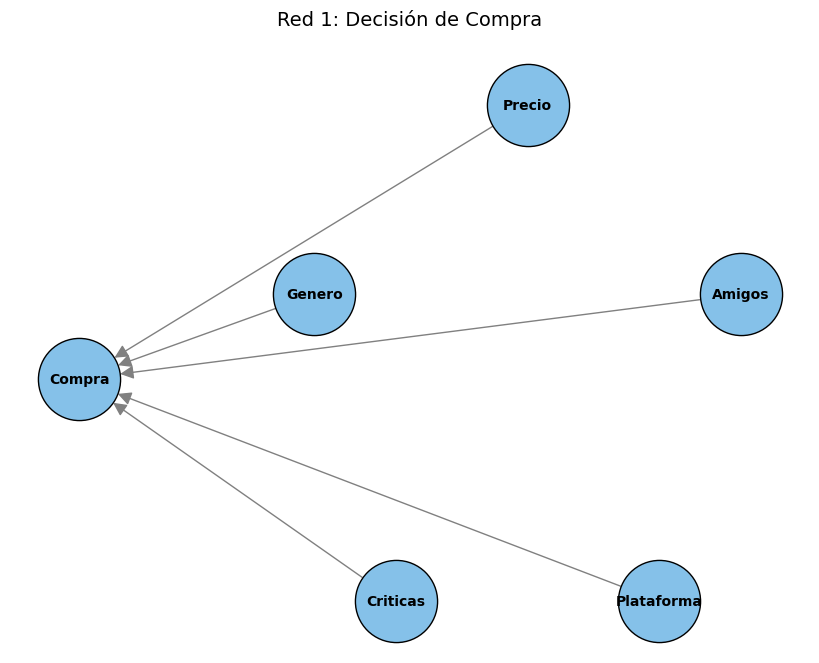

In [22]:
model_compra = DiscreteBayesianNetwork([
    ('Precio', 'Compra'), ('Genero', 'Compra'), 
    ('Criticas', 'Compra'), ('Plataforma', 'Compra'), ('Amigos', 'Compra')
])

cpd_p = TabularCPD('Precio', 3, [[0.3], [0.5], [0.2]], state_names={'Precio': ['Alto', 'Medio', 'Bajo']})
cpd_g = TabularCPD('Genero', 4, [[0.4], [0.3], [0.2], [0.1]], state_names={'Genero': ['Accion', 'Aventura', 'Estrategia', 'Otros']})
cpd_cp = TabularCPD('Criticas', 2, [[0.7], [0.3]], state_names={'Criticas': ['Alta', 'Baja']})
cpd_pl = TabularCPD('Plataforma', 2, [[0.6], [0.4]], state_names={'Plataforma': ['Consola', 'PC']})
cpd_a = TabularCPD('Amigos', 2, [[0.4], [0.6]], state_names={'Amigos': ['Si', 'No']})

val_c = np.random.rand(2, 96)
val_c /= val_c.sum(axis=0)

cpd_compra = TabularCPD(
    variable='Compra', variable_card=2, values=val_c,
    evidence=['Precio', 'Genero', 'Criticas', 'Plataforma', 'Amigos'],
    evidence_card=[3, 4, 2, 2, 2],
    state_names={'Compra': ['Si', 'No'], 'Precio': ['Alto', 'Medio', 'Bajo'], 
                 'Genero': ['Accion', 'Aventura', 'Estrategia', 'Otros'], 
                 'Criticas': ['Alta', 'Baja'], 'Plataforma': ['Consola', 'PC'], 'Amigos': ['Si', 'No']}
)

model_compra.add_cpds(cpd_p, cpd_g, cpd_cp, cpd_pl, cpd_a, cpd_compra)
graficar_red(model_compra, "Red 1: Decisión de Compra", "#85C1E9")

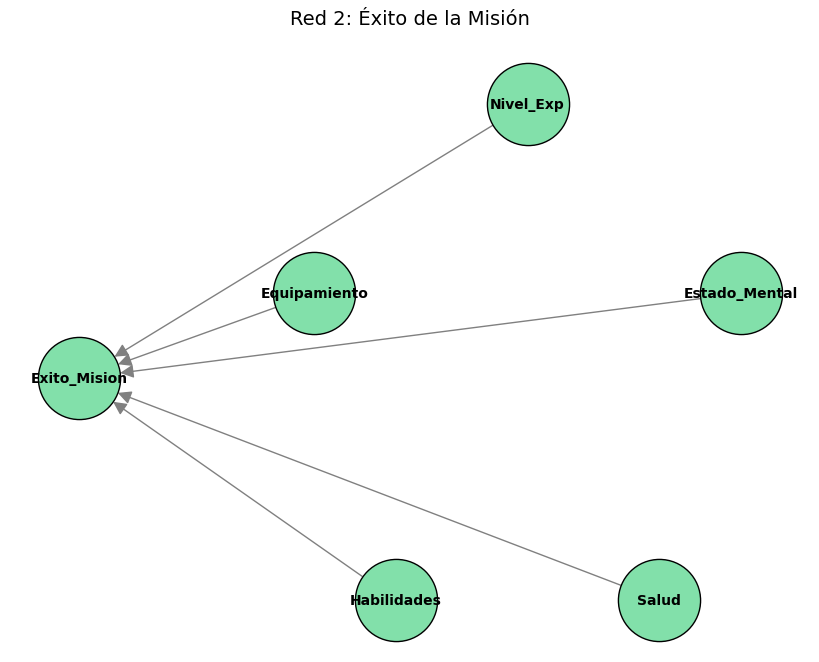

In [25]:
model_mision = DiscreteBayesianNetwork([
    ('Nivel_Exp', 'Exito_Mision'), ('Equipamiento', 'Exito_Mision'),
    ('Habilidades', 'Exito_Mision'), ('Salud', 'Exito_Mision'), ('Estado_Mental', 'Exito_Mision')
])

cpd_ne = TabularCPD('Nivel_Exp', 3, [[0.4], [0.4], [0.2]], state_names={'Nivel_Exp': ['Bajo', 'Medio', 'Alto']})
cpd_eq = TabularCPD('Equipamiento', 3, [[0.5], [0.3], [0.2]], state_names={'Equipamiento': ['Basico', 'Intermedio', 'Avanzado']})
cpd_h = TabularCPD('Habilidades', 3, [[0.3], [0.5], [0.2]], state_names={'Habilidades': ['Bajas', 'Medias', 'Altas']})
cpd_s = TabularCPD('Salud', 3, [[0.2], [0.5], [0.3]], state_names={'Salud': ['Baja', 'Media', 'Alta']})
cpd_eme = TabularCPD('Estado_Mental', 3, [[0.2], [0.6], [0.2]], state_names={'Estado_Mental': ['Negativo', 'Neutral', 'Positivo']})

val_e = np.random.rand(2, 243)
val_e /= val_e.sum(axis=0)

cpd_exito = TabularCPD(
    variable='Exito_Mision', variable_card=2, values=val_e,
    evidence=['Nivel_Exp', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental'],
    evidence_card=[3, 3, 3, 3, 3],
    state_names={'Exito_Mision': ['Si', 'No'], 'Nivel_Exp': ['Bajo', 'Medio', 'Alto'],
                 'Equipamiento': ['Basico', 'Intermedio', 'Avanzado'], 'Habilidades': ['Bajas', 'Medias', 'Altas'],
                 'Salud': ['Baja', 'Media', 'Alta'], 'Estado_Mental': ['Negativo', 'Neutral', 'Positivo']}
)

model_mision.add_cpds(cpd_ne, cpd_eq, cpd_h, cpd_s, cpd_eme, cpd_exito)
graficar_red(model_mision, "Red 2: Éxito de la Misión", "#82E0AA")

In [26]:
infer1 = VariableElimination(model_compra)
print("Consulta Compra (Precio Bajo + Amigos):")
print(infer1.query(variables=['Compra'], evidence={'Precio': 'Bajo', 'Amigos': 'Si'}))

infer2 = VariableElimination(model_mision)
print("\nConsulta Misión (Salud Alta + Equipo Avanzado):")
print(infer2.query(variables=['Exito_Mision'], evidence={'Salud': 'Alta', 'Equipamiento': 'Avanzado'}))

Consulta Compra (Precio Bajo + Amigos):
+------------+---------------+
| Compra     |   phi(Compra) |
+============+===============+
| Compra(Si) |        0.5207 |
+------------+---------------+
| Compra(No) |        0.4793 |
+------------+---------------+

Consulta Misión (Salud Alta + Equipo Avanzado):
+------------------+---------------------+
| Exito_Mision     |   phi(Exito_Mision) |
+==================+=====================+
| Exito_Mision(Si) |              0.5246 |
+------------------+---------------------+
| Exito_Mision(No) |              0.4754 |
+------------------+---------------------+
